<a href="https://www.kaggle.com/code/omborse771924/nasa-power-climate-risk-extremes?scriptVersionId=324002162" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kanchana1990/nasa-power-climate-risk-and-extremes/nasa_power_climate_risk_indices_190_capitals_1990_2024.csv


## Loading Dataset

In [2]:
df=pd.read_csv('/kaggle/input/datasets/kanchana1990/nasa-power-climate-risk-and-extremes/nasa_power_climate_risk_indices_190_capitals_1990_2024.csv')

In [3]:
df.head()

,city,iso_alpha3,latitude,longitude,continent,who_region,wb_income_group,year,data_days,temp_mean_c,...,solar_clearness_idx,solar_peak_days,solar_annual_kwh_m2,pressure_mean_kpa,pressure_std_kpa,climate_volatility,gdp_per_capita_usd,population,urban_pop_pct,energy_use_kg_oil_eq
0,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1990,365.0,27.695068,...,NaN,0.0,579.30,100.775370,0.801732,0.1810,26709.993440,1898220.0,78.685768,10740.842922
1,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1991,365.0,27.084274,...,NaN,0.0,556.38,100.800055,0.766893,0.0809,25690.968632,2006626.0,78.553863,11690.097020
2,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1992,366.0,26.680383,...,NaN,0.0,546.73,100.900656,0.778965,0.3512,25648.272776,2114730.0,78.441374,10562.899438
3,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1993,365.0,27.617425,...,NaN,0.0,571.01,100.864959,0.770028,0.5771,25032.782270,2222093.0,78.351924,10572.669831
4,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1994,365.0,27.643479,...,NaN,0.0,565.40,100.801123,0.834037,0.0204,25472.639658,2328188.0,78.289134,11178.398481


In [4]:
df.tail()

,city,iso_alpha3,latitude,longitude,continent,who_region,wb_income_group,year,data_days,temp_mean_c,...,solar_clearness_idx,solar_peak_days,solar_annual_kwh_m2,pressure_mean_kpa,pressure_std_kpa,climate_volatility,gdp_per_capita_usd,population,urban_pop_pct,energy_use_kg_oil_eq
6645,Zagreb,HRV,45.81,15.98,Europe,EUR,High,2020,366.0,11.571475,...,0.495301,0.0,386.43,99.425546,0.778245,3.3412,14807.560854,3914206.0,56.528486,2104.845306
6646,Zagreb,HRV,45.81,15.98,Europe,EUR,High,2021,365.0,11.235315,...,0.485151,0.0,383.06,99.355425,0.734905,3.3534,17788.786582,3878981.0,56.768350,2212.497211
6647,Zagreb,HRV,45.81,15.98,Europe,EUR,High,2022,365.0,12.277863,...,0.491671,0.0,386.18,99.477644,0.744171,3.4615,18465.541442,3855641.0,56.997757,2154.954833
6648,Zagreb,HRV,45.81,15.98,Europe,EUR,High,2023,365.0,12.368575,...,0.470164,0.0,363.65,99.254712,0.789971,4.0202,22184.227930,3859686.0,57.243156,2237.233699
6649,Zagreb,HRV,45.81,15.98,Europe,EUR,High,2024,366.0,13.187842,...,0.477541,0.0,369.97,99.320984,0.789348,3.3885,24050.439793,3866200.0,57.515898,NaN


In [5]:
df.describe()

,latitude,longitude,year,data_days,temp_mean_c,temp_max_c,temp_min_c,temp_std_c,temp_range_mean_c,temp_seasonal_amp,...,solar_clearness_idx,solar_peak_days,solar_annual_kwh_m2,pressure_mean_kpa,pressure_std_kpa,climate_volatility,gdp_per_capita_usd,population,urban_pop_pct,energy_use_kg_oil_eq
count,6650.000000,6650.000000,6650.000000,6650.000000,6650.000000,6650.000000,6650.000000,6650.000000,6650.000000,6650.000000,...,4560.000000,6650.0,6650.000000,6650.000000,6650.000000,6650.000000,6465.000000,6.580000e+03,6580.000000,5050.000000
mean,18.572421,22.186158,2007.000000,367.179549,19.676911,34.612319,5.021768,4.662159,8.022112,12.745047,...,0.536499,0.0,489.724138,96.442585,0.435515,1.565950,10944.947814,3.555906e+07,54.797910,2274.443035
std,24.232271,66.202217,10.100264,26.434372,7.560244,5.565391,15.394534,3.517533,4.264271,9.775679,...,0.074366,0.0,108.850770,6.426781,0.303449,2.198223,18783.848991,1.330653e+08,23.016545,2757.956448
min,-41.290000,-175.200000,1990.000000,365.000000,-3.075355,15.550000,-45.040000,0.346657,0.546858,0.330968,...,0.365726,0.0,213.390000,67.358388,0.069549,0.003300,22.952133,8.798000e+03,5.274941,0.000000
25%,3.870000,-6.830000,1998.000000,365.000000,13.222832,30.400000,-6.567500,1.311086,4.622017,3.548487,...,0.481500,0.0,423.240000,93.720856,0.163692,0.248825,1014.402797,1.956066e+06,35.424115,496.586814
50%,15.450000,21.090000,2007.000000,365.000000,21.572223,34.100000,7.585000,3.784264,8.589868,10.363357,...,0.543712,0.0,507.275000,99.460219,0.350805,0.655950,3435.288047,7.381301e+06,55.623062,1249.437479
75%,39.920000,49.870000,2016.000000,366.000000,26.564868,38.587500,18.607500,7.737957,11.133192,21.206752,...,0.594252,0.0,563.645000,100.849740,0.656594,2.032200,11501.226519,2.312902e+07,73.249034,2893.639612
max,64.140000,179.200000,2024.000000,732.000000,30.141311,52.640000,26.950000,17.462571,17.059126,46.194194,...,0.706384,0.0,1185.660000,101.945863,1.684677,30.616700,206780.590353,1.450936e+09,100.000000,21557.475076


In [6]:
df.isnull()

,city,iso_alpha3,latitude,longitude,continent,who_region,wb_income_group,year,data_days,temp_mean_c,...,solar_clearness_idx,solar_peak_days,solar_annual_kwh_m2,pressure_mean_kpa,pressure_std_kpa,climate_volatility,gdp_per_capita_usd,population,urban_pop_pct,energy_use_kg_oil_eq
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6645,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6646,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6647,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6648,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

city                       0
iso_alpha3                 0
latitude                   0
longitude                  0
continent                  0
who_region                 0
wb_income_group            0
year                       0
data_days                  0
temp_mean_c                0
temp_max_c                 0
temp_min_c                 0
temp_std_c                 0
temp_range_mean_c          0
temp_seasonal_amp          0
temp_yoy_change          190
temp_5yr_mean            380
temp_anomaly             380
days_above_35c             0
days_above_40c             0
days_below_0c              0
days_below_minus10c        0
heat_stress_index          0
cold_stress_index          0
drought_stress_days        0
ideal_climate_days         0
precip_total_mm            0
precip_mean_mm             0
precip_max_day_mm          0
precip_std_mm              0
precip_yoy_change        190
days_heavy_rain            0
days_moderate_rain         0
days_dry                   0
rh_mean_pct   

In [8]:
missing_cols = [

    'temp_yoy_change',
    'temp_5yr_mean',
    'temp_anomaly',
    'precip_yoy_change',
    'solar_clearness_idx',
    'gdp_per_capita_usd',
    'population',
    'urban_pop_pct',
    'energy_use_kg_oil_eq'

]


for col in missing_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )

In [9]:
df.isnull().sum()

city                    0
iso_alpha3              0
latitude                0
longitude               0
continent               0
who_region              0
wb_income_group         0
year                    0
data_days               0
temp_mean_c             0
temp_max_c              0
temp_min_c              0
temp_std_c              0
temp_range_mean_c       0
temp_seasonal_amp       0
temp_yoy_change         0
temp_5yr_mean           0
temp_anomaly            0
days_above_35c          0
days_above_40c          0
days_below_0c           0
days_below_minus10c     0
heat_stress_index       0
cold_stress_index       0
drought_stress_days     0
ideal_climate_days      0
precip_total_mm         0
precip_mean_mm          0
precip_max_day_mm       0
precip_std_mm           0
precip_yoy_change       0
days_heavy_rain         0
days_moderate_rain      0
days_dry                0
rh_mean_pct             0
rh_max_pct              0
dewpoint_mean_c         0
humidity_stress_days    0
wind_mean_ms

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6645    False
6646    False
6647    False
6648    False
6649    False
Length: 6650, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['city', 'iso_alpha3', 'latitude', 'longitude', 'continent',
       'who_region', 'wb_income_group', 'year', 'data_days', 'temp_mean_c',
       'temp_max_c', 'temp_min_c', 'temp_std_c', 'temp_range_mean_c',
       'temp_seasonal_amp', 'temp_yoy_change', 'temp_5yr_mean', 'temp_anomaly',
       'days_above_35c', 'days_above_40c', 'days_below_0c',
       'days_below_minus10c', 'heat_stress_index', 'cold_stress_index',
       'drought_stress_days', 'ideal_climate_days', 'precip_total_mm',
       'precip_mean_mm', 'precip_max_day_mm', 'precip_std_mm',
       'precip_yoy_change', 'days_heavy_rain', 'days_moderate_rain',
       'days_dry', 'rh_mean_pct', 'rh_max_pct', 'dewpoint_mean_c',
       'humidity_stress_days', 'wind_mean_ms', 'wind_max_ms', 'wind_std_ms',
       'high_wind_days', 'wind_power_density', 'solar_total_mj',
       'solar_mean_mj', 'solar_clear_mean_mj', 'solar_clearness_idx',
       'solar_peak_days', 'solar_annual_kwh_m2', 'pressure_mean_kpa',
       'pressure_std_kp

## EDA

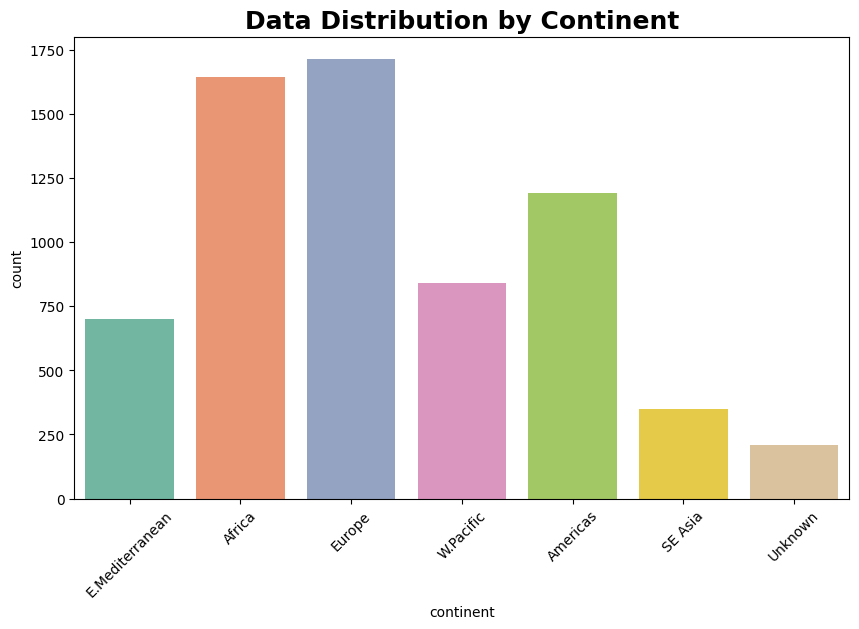

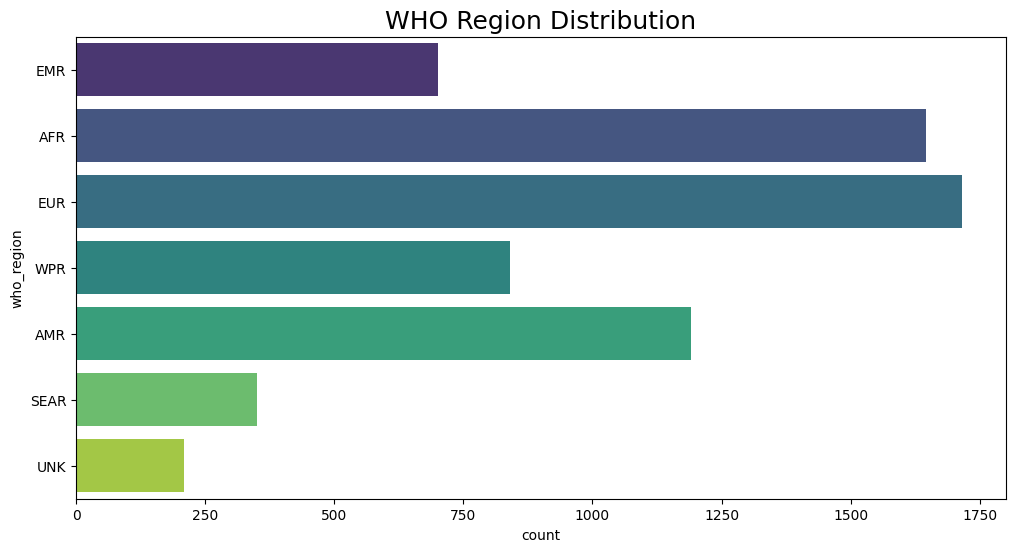

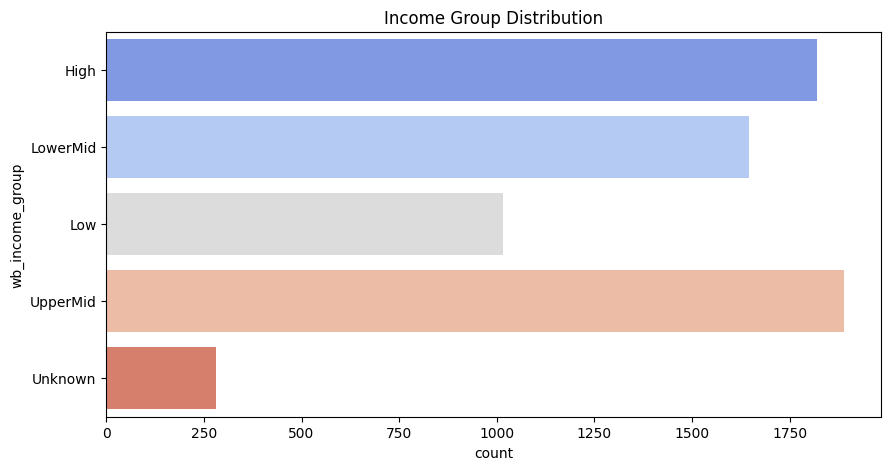

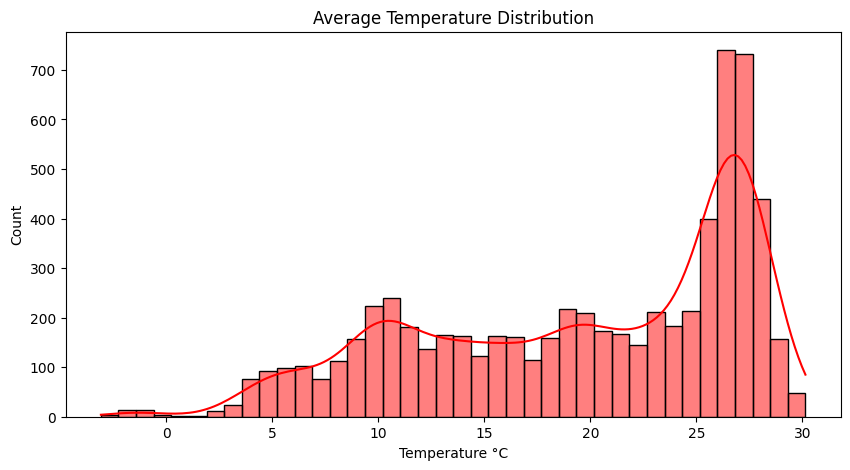

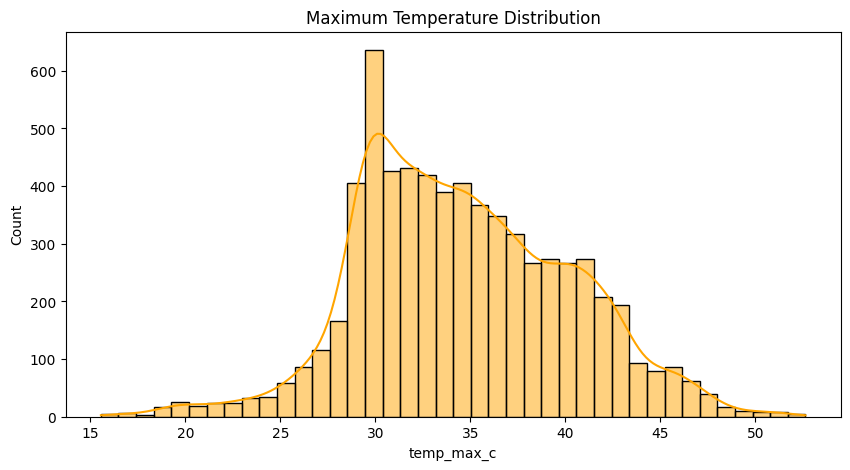

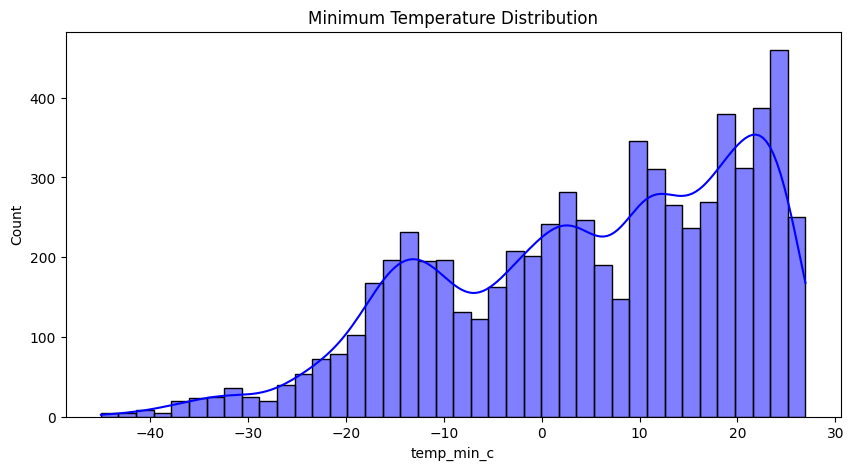

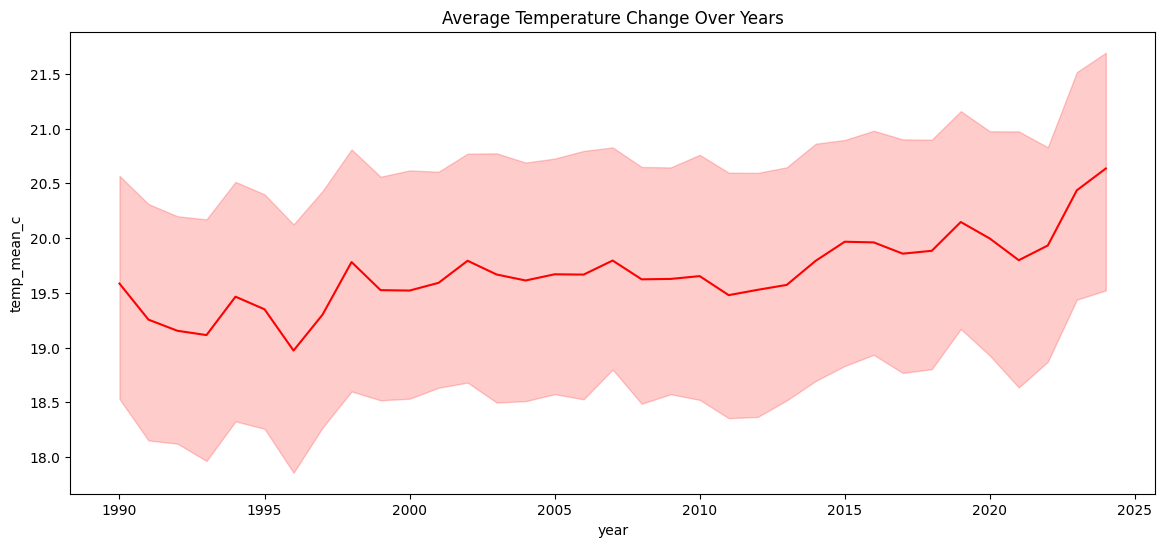

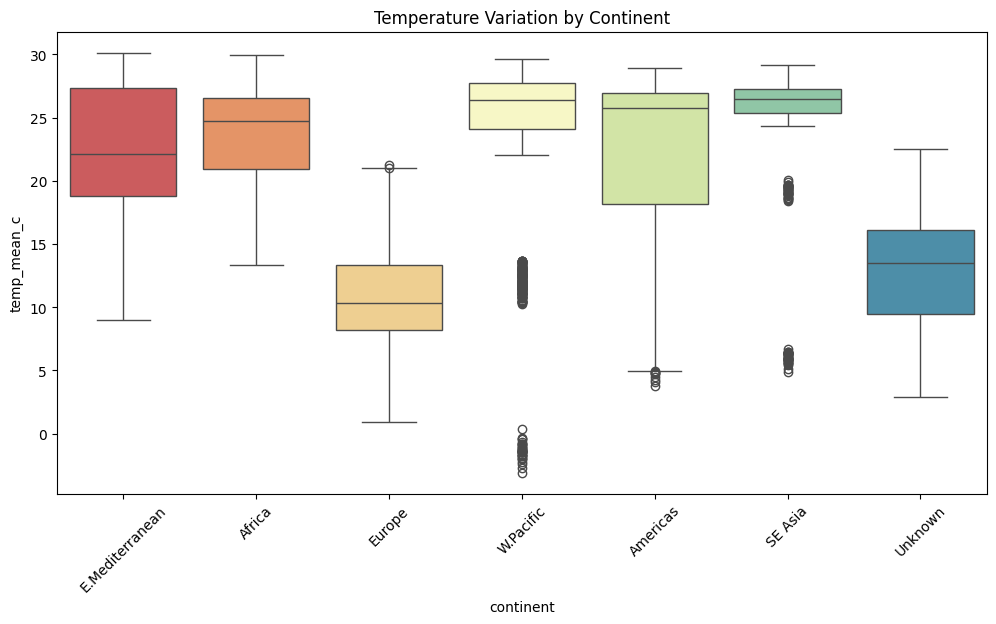

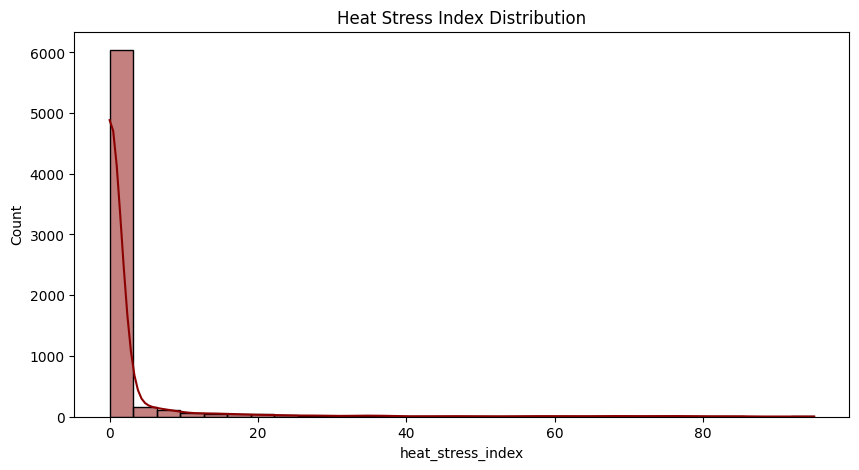

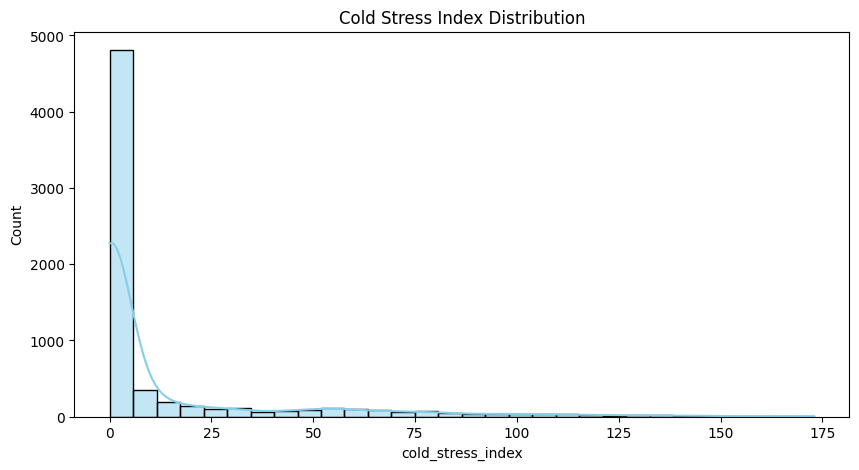

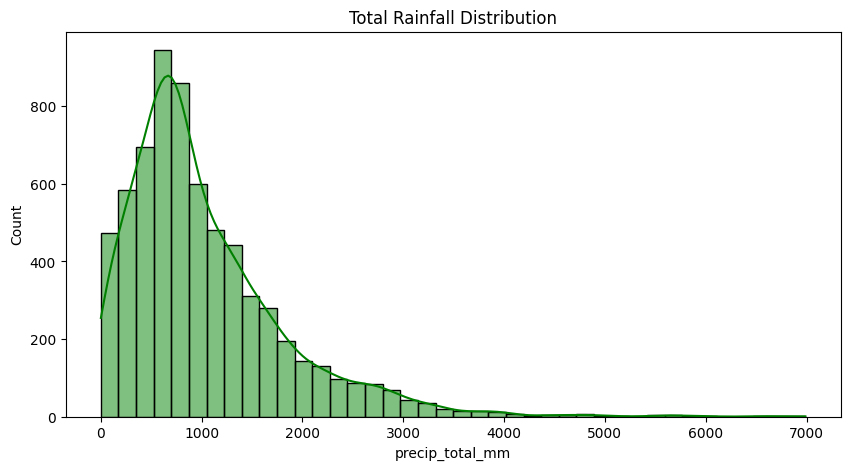

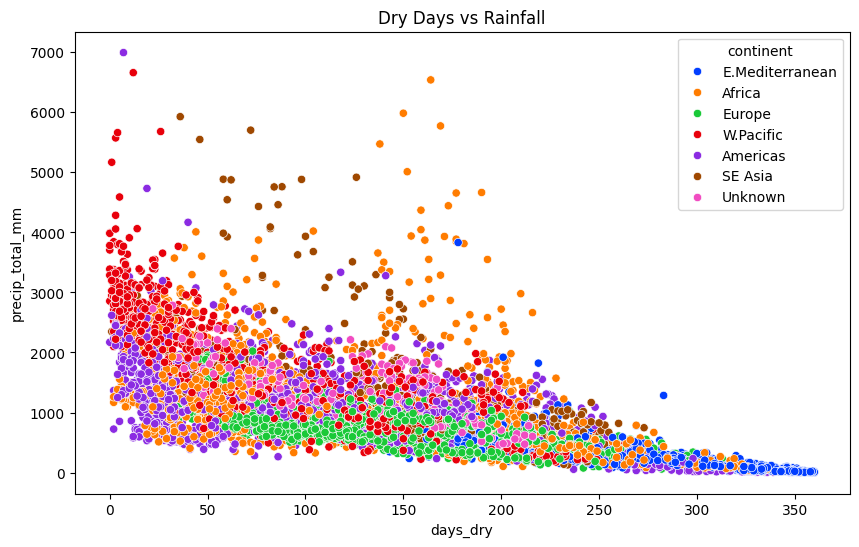

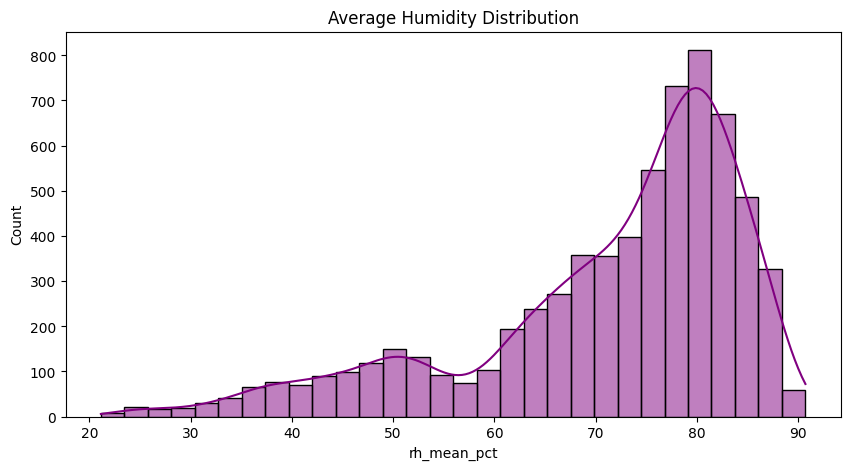

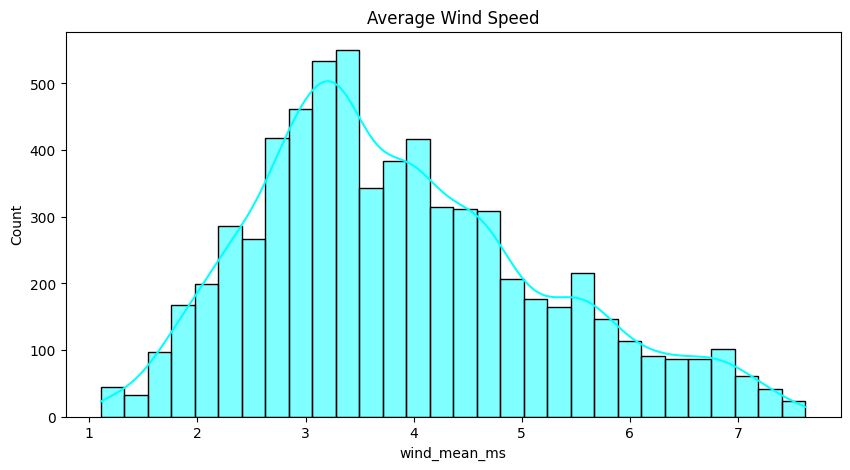

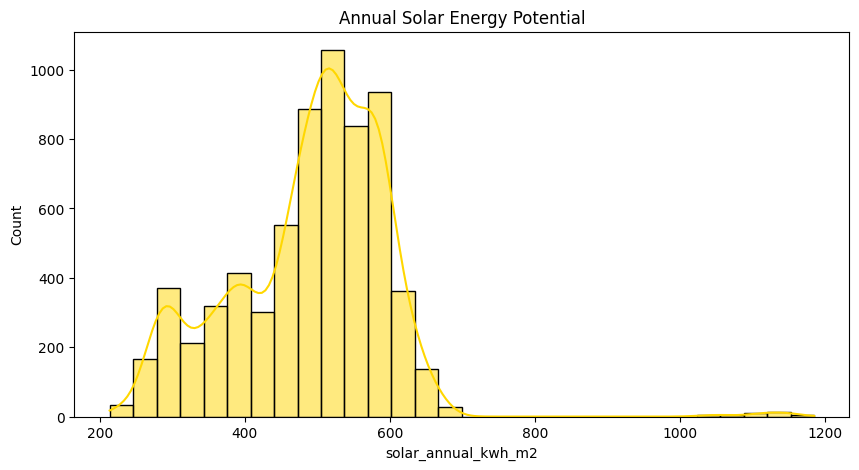

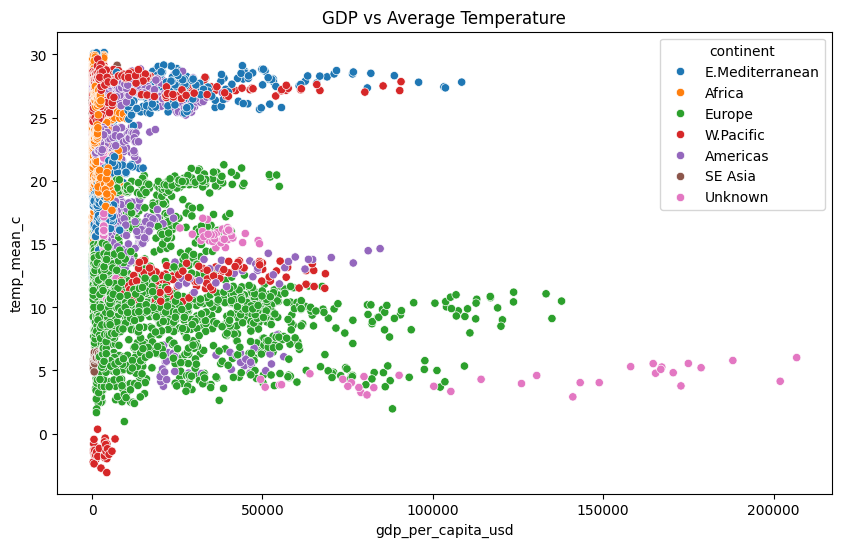

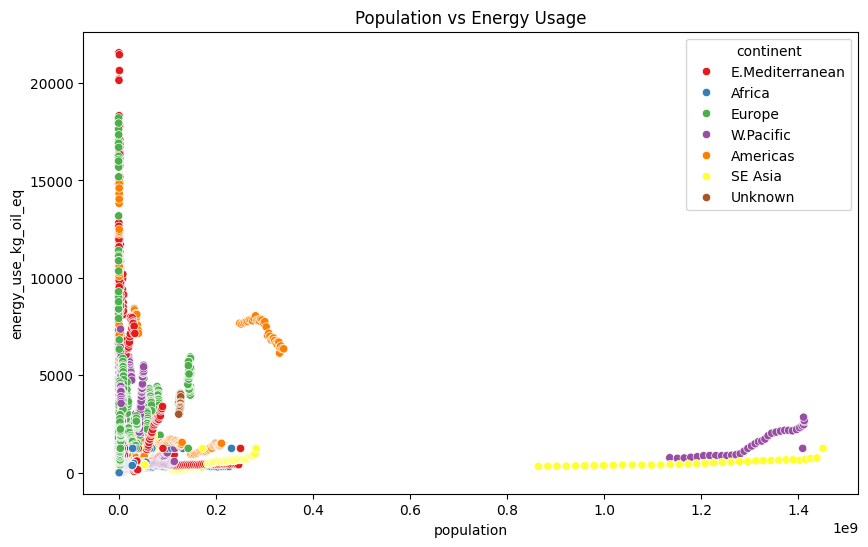

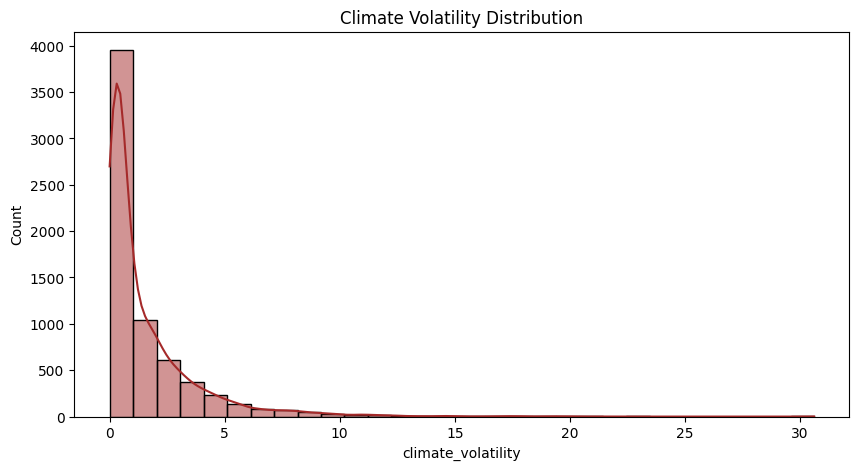

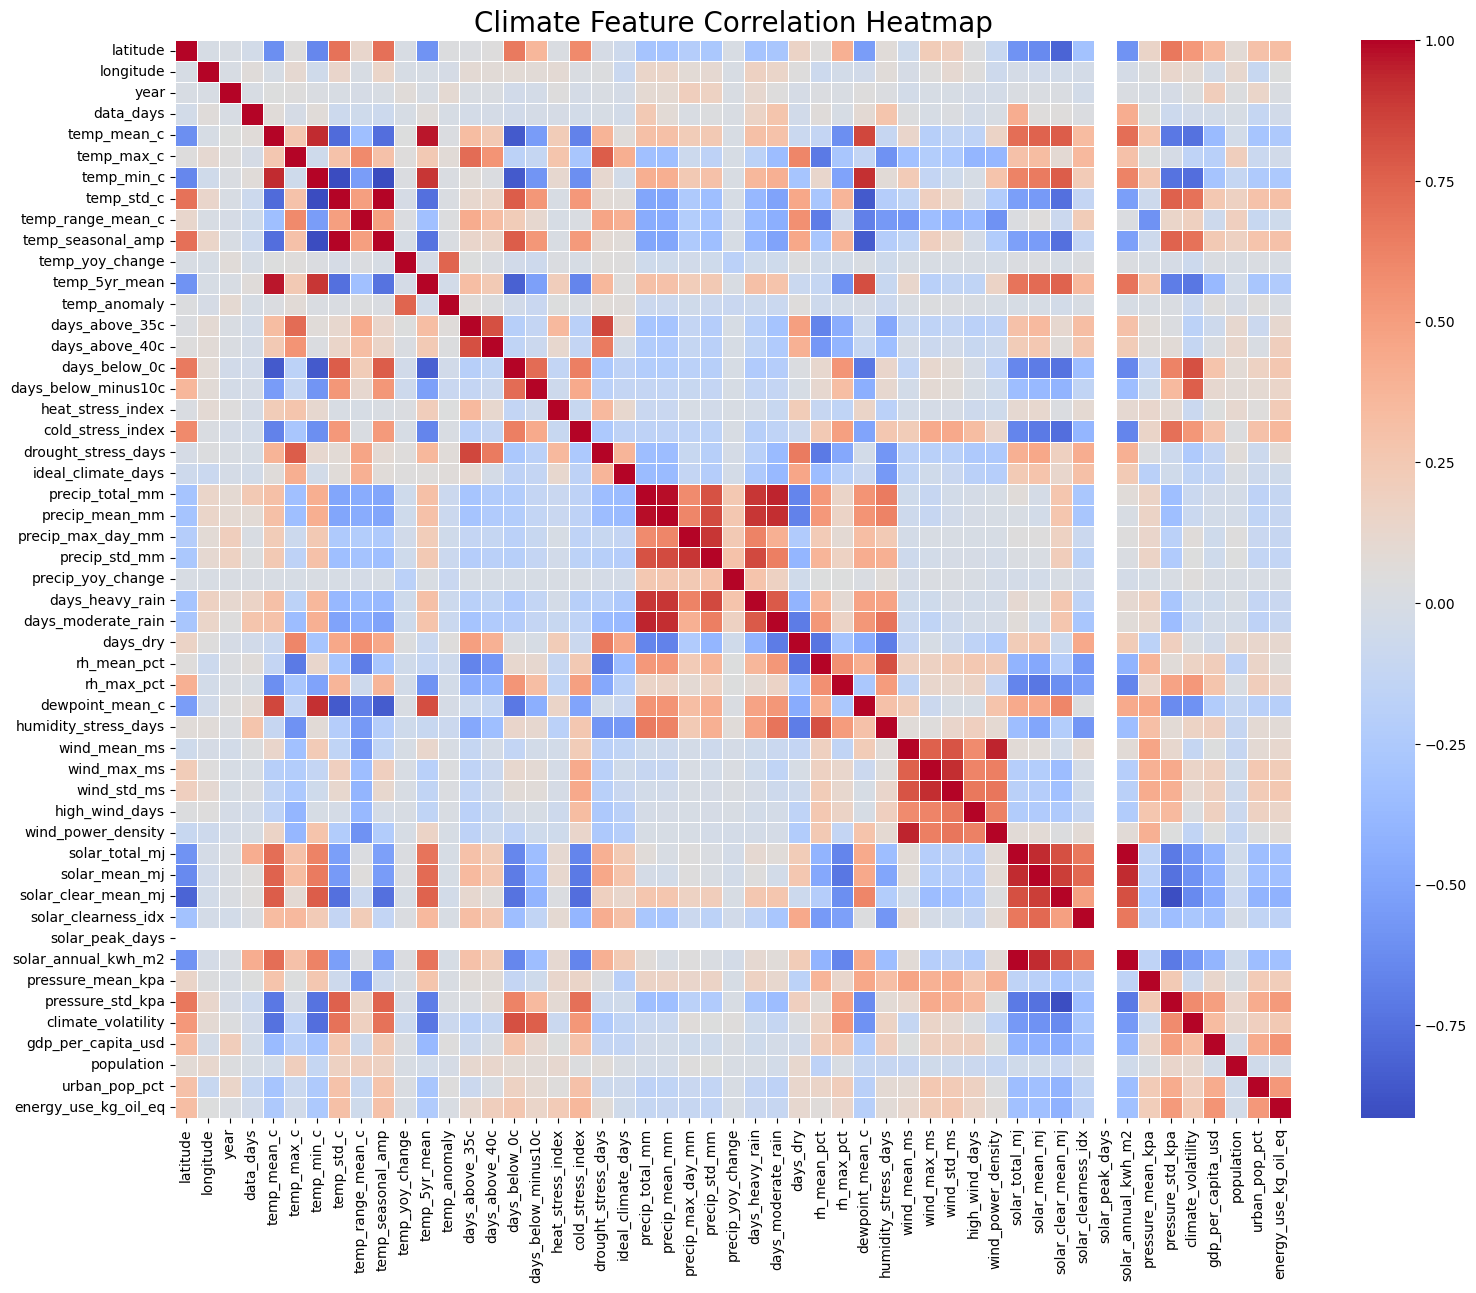

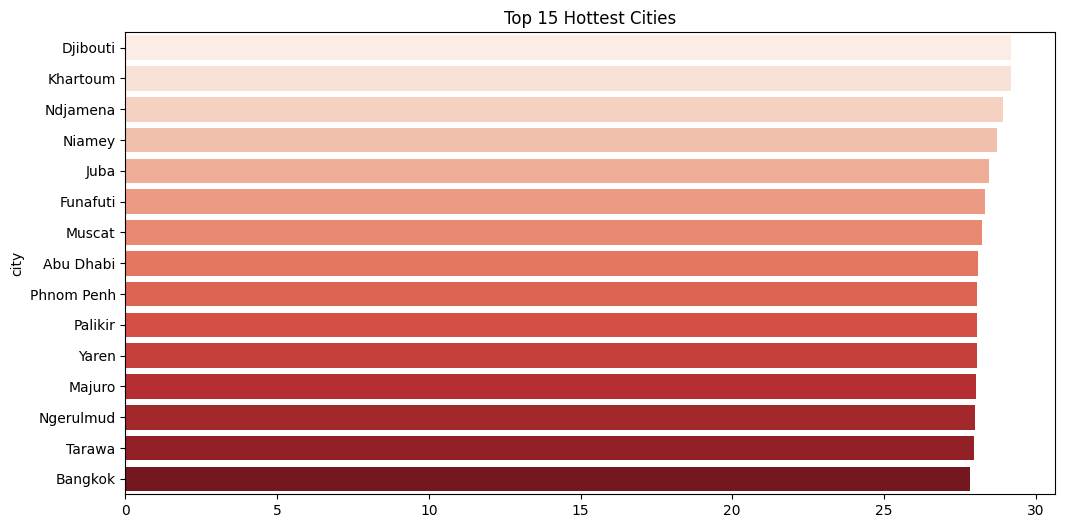

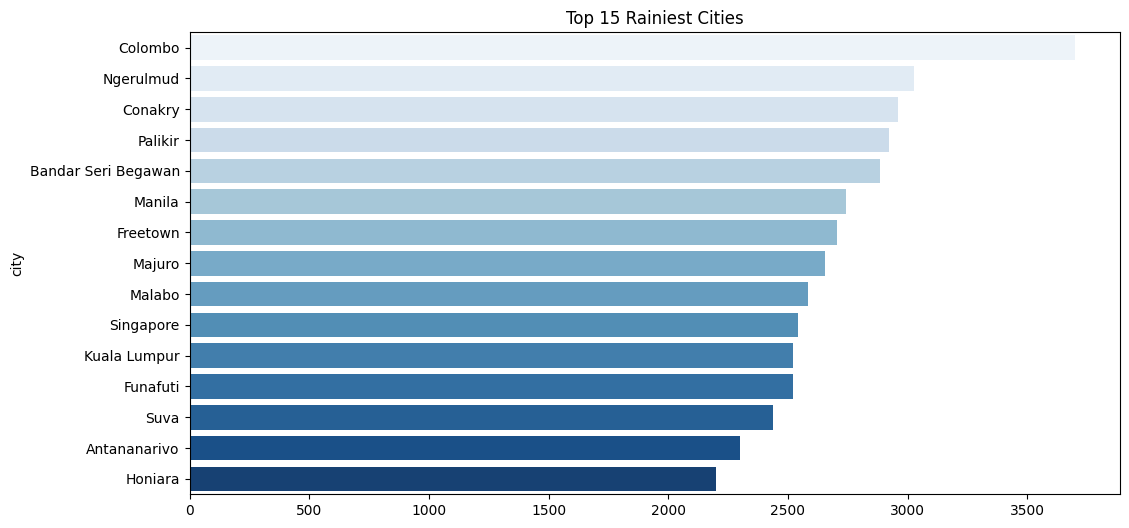

Detailed Climate EDA Completed Successfully!


In [13]:
# =====================================================
# 1. CONTINENT DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='continent',
    data=df,
    palette='Set2'
)

plt.title(
    "Data Distribution by Continent",
    fontsize=18,
    weight='bold'
)

plt.xticks(rotation=45)

plt.show()



# =====================================================
# 2. WHO REGION DISTRIBUTION
# =====================================================

plt.figure(figsize=(12,6))


sns.countplot(
    y='who_region',
    data=df,
    palette='viridis'
)


plt.title(
    "WHO Region Distribution",
    fontsize=18
)


plt.show()



# =====================================================
# 3. WORLD BANK INCOME GROUP
# =====================================================

plt.figure(figsize=(10,5))


sns.countplot(
    y='wb_income_group',
    data=df,
    palette='coolwarm'
)


plt.title(
    "Income Group Distribution"
)


plt.show()




# =====================================================
# 4. TEMPERATURE MEAN DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['temp_mean_c'],
    bins=40,
    kde=True,
    color='red'
)


plt.title(
    "Average Temperature Distribution"
)


plt.xlabel(
    "Temperature °C"
)


plt.show()




# =====================================================
# 5. MAX TEMPERATURE DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['temp_max_c'],
    bins=40,
    kde=True,
    color='orange'
)


plt.title(
    "Maximum Temperature Distribution"
)


plt.show()




# =====================================================
# 6. MIN TEMPERATURE DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['temp_min_c'],
    bins=40,
    kde=True,
    color='blue'
)


plt.title(
    "Minimum Temperature Distribution"
)


plt.show()




# =====================================================
# 7. TEMPERATURE CHANGE OVER YEARS
# =====================================================

plt.figure(figsize=(14,6))


sns.lineplot(
    x='year',
    y='temp_mean_c',
    data=df,
    color='red'
)


plt.title(
    "Average Temperature Change Over Years"
)


plt.show()




# =====================================================
# 8. TEMPERATURE BY CONTINENT
# =====================================================

plt.figure(figsize=(12,6))


sns.boxplot(
    x='continent',
    y='temp_mean_c',
    data=df,
    palette='Spectral'
)


plt.title(
    "Temperature Variation by Continent"
)


plt.xticks(rotation=45)


plt.show()




# =====================================================
# 9. HEAT STRESS INDEX
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['heat_stress_index'],
    bins=30,
    kde=True,
    color='darkred'
)


plt.title(
    "Heat Stress Index Distribution"
)


plt.show()




# =====================================================
# 10. COLD STRESS INDEX
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['cold_stress_index'],
    bins=30,
    kde=True,
    color='skyblue'
)


plt.title(
    "Cold Stress Index Distribution"
)


plt.show()




# =====================================================
# 11. PRECIPITATION DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['precip_total_mm'],
    bins=40,
    kde=True,
    color='green'
)


plt.title(
    "Total Rainfall Distribution"
)


plt.show()




# =====================================================
# 12. DRY DAYS VS RAIN
# =====================================================

plt.figure(figsize=(10,6))


sns.scatterplot(
    x='days_dry',
    y='precip_total_mm',
    hue='continent',
    data=df,
    palette='bright'
)


plt.title(
    "Dry Days vs Rainfall"
)


plt.show()




# =====================================================
# 13. HUMIDITY DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['rh_mean_pct'],
    bins=30,
    kde=True,
    color='purple'
)


plt.title(
    "Average Humidity Distribution"
)


plt.show()




# =====================================================
# 14. WIND SPEED
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['wind_mean_ms'],
    kde=True,
    bins=30,
    color='cyan'
)


plt.title(
    "Average Wind Speed"
)


plt.show()




# =====================================================
# 15. SOLAR ENERGY DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['solar_annual_kwh_m2'],
    bins=30,
    kde=True,
    color='gold'
)


plt.title(
    "Annual Solar Energy Potential"
)


plt.show()




# =====================================================
# 16. GDP VS TEMPERATURE
# =====================================================

plt.figure(figsize=(10,6))


sns.scatterplot(
    x='gdp_per_capita_usd',
    y='temp_mean_c',
    hue='continent',
    data=df,
    palette='tab10'
)


plt.title(
    "GDP vs Average Temperature"
)


plt.show()




# =====================================================
# 17. POPULATION VS ENERGY USE
# =====================================================

plt.figure(figsize=(10,6))


sns.scatterplot(
    x='population',
    y='energy_use_kg_oil_eq',
    hue='continent',
    data=df,
    palette='Set1'
)


plt.title(
    "Population vs Energy Usage"
)


plt.show()




# =====================================================
# 18. CLIMATE VOLATILITY
# =====================================================

plt.figure(figsize=(10,5))


sns.histplot(
    df['climate_volatility'],
    kde=True,
    bins=30,
    color='brown'
)


plt.title(
    "Climate Volatility Distribution"
)


plt.show()



# =====================================================
# 19. CORRELATION HEATMAP
# =====================================================


numeric_df = df.select_dtypes(
    include=np.number
)


plt.figure(figsize=(18,14))


sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    linewidths=0.5
)


plt.title(
    "Climate Feature Correlation Heatmap",
    fontsize=20
)


plt.show()



# =====================================================
# 20. TOP HOTTEST CITIES
# =====================================================


hot = df.groupby(
    'city'
)['temp_mean_c'].mean().sort_values(
    ascending=False
).head(15)



plt.figure(figsize=(12,6))


sns.barplot(
    x=hot.values,
    y=hot.index,
    palette='Reds'
)


plt.title(
    "Top 15 Hottest Cities"
)


plt.show()




# =====================================================
# 21. TOP RAINIEST CITIES
# =====================================================


rain = df.groupby(
    'city'
)['precip_total_mm'].mean().sort_values(
    ascending=False
).head(15)



plt.figure(figsize=(12,6))


sns.barplot(
    x=rain.values,
    y=rain.index,
    palette='Blues'
)


plt.title(
    "Top 15 Rainiest Cities"
)


plt.show()



# =====================================================
# FINISH
# =====================================================

print(
    "Detailed Climate EDA Completed Successfully!"
)

## Features Engineering

0
(6650, 55) (6650,)

Logistic Regression
Accuracy: 0.915
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       444
           1       0.93      0.93      0.93       443
           2       0.86      0.88      0.87       443

    accuracy                           0.92      1330
   macro avg       0.92      0.92      0.92      1330
weighted avg       0.92      0.92      0.92      1330


Decision Tree
Accuracy: 0.9308
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       444
           1       0.96      0.95      0.95       443
           2       0.89      0.90      0.90       443

    accuracy                           0.93      1330
   macro avg       0.93      0.93      0.93      1330
weighted avg       0.93      0.93      0.93      1330


Random Forest
Accuracy: 0.9436
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       444
       

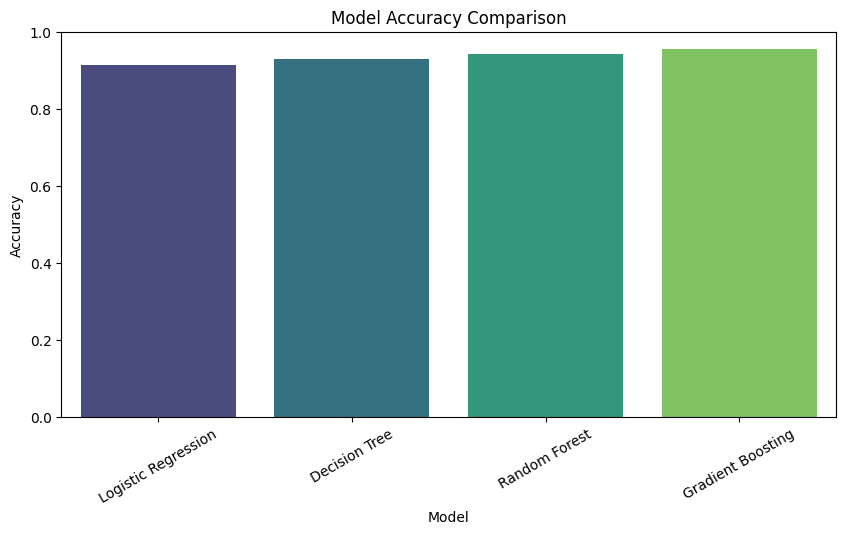

Best Model: Gradient Boosting


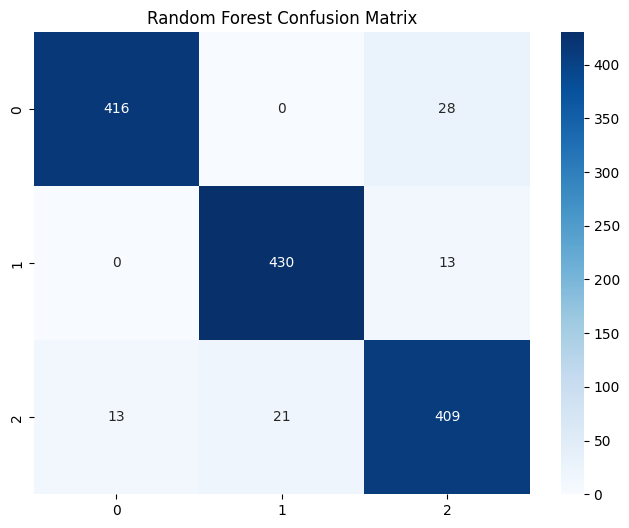

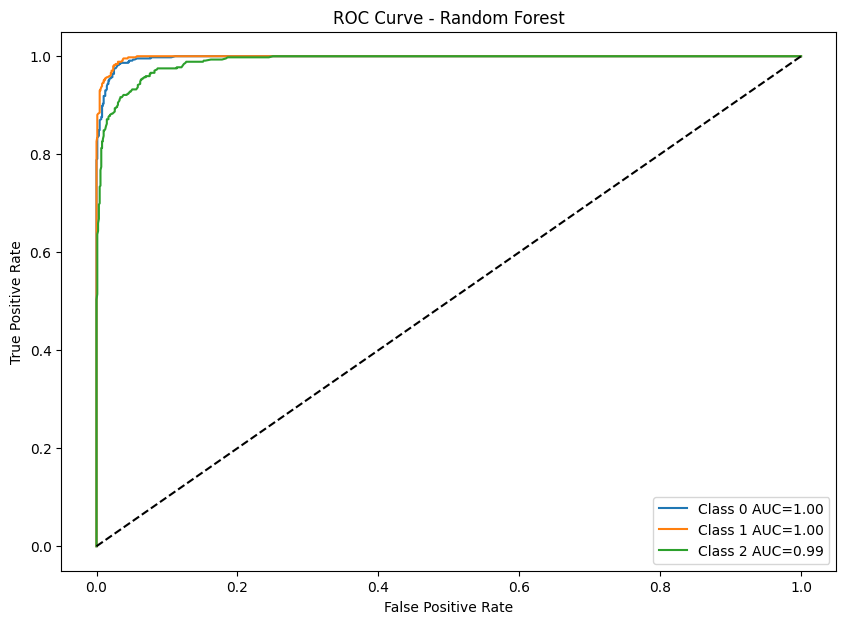

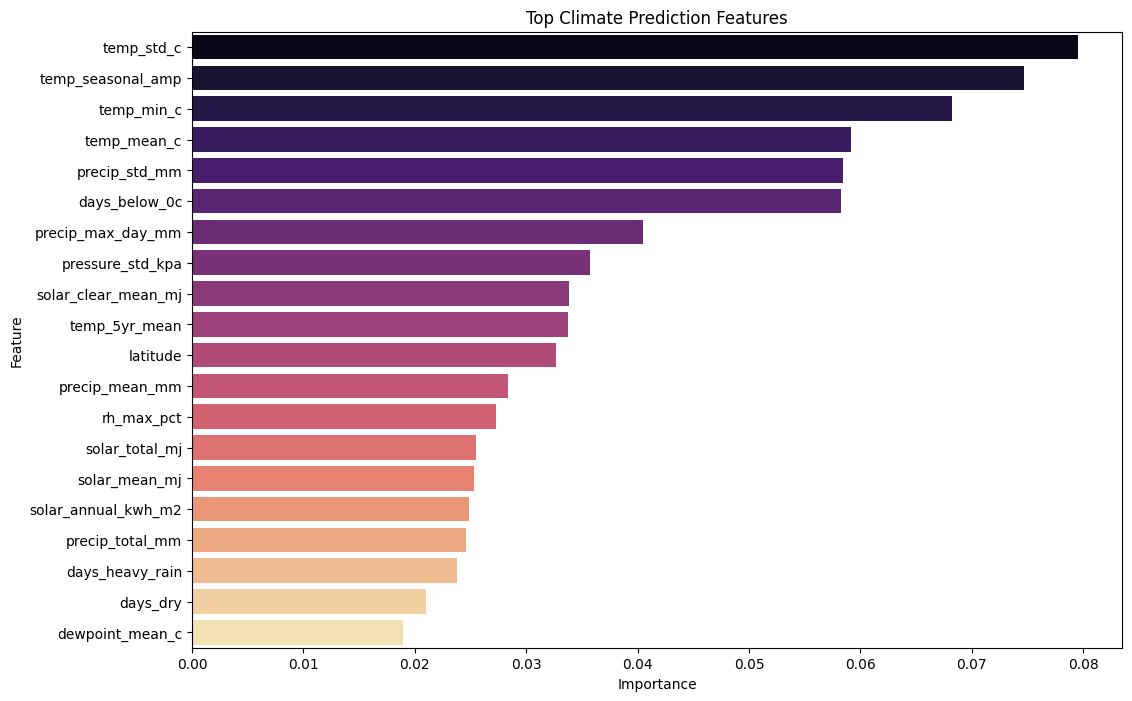


FINAL RESULTS
Logistic Regression : 0.915
Decision Tree : 0.9308
Random Forest : 0.9436
Gradient Boosting : 0.9571
Best: Gradient Boosting


In [14]:



from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)







# ============================================================
# HANDLE NULL VALUES
# ============================================================

for col in df.columns:

    if df[col].dtype!="object":

        df[col] = df[col].fillna(
            df[col].median()
        )

    else:

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )



print(
    df.isnull().sum().sum()
)




# ============================================================
# CREATE TARGET VARIABLE
# ============================================================

df['Climate_Risk_Level'] = pd.qcut(

    df['climate_volatility'],

    q=3,

    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


# remove original leakage column

df.drop(
    'climate_volatility',
    axis=1,
    inplace=True
)



# ============================================================
# LABEL ENCODING
# ============================================================

encoders={}


for col in df.columns:


    if df[col].dtype=="object":


        le=LabelEncoder()


        df[col]=le.fit_transform(
            df[col].astype(str)
        )


        encoders[col]=le




# Encode Target

target_encoder=LabelEncoder()


df['Climate_Risk_Level']=target_encoder.fit_transform(

    df['Climate_Risk_Level']

)



# ============================================================
# FEATURES AND TARGET
# ============================================================

X=df.drop(

    "Climate_Risk_Level",

    axis=1

)


y=df[
    "Climate_Risk_Level"
]


print(
    X.shape,
    y.shape
)



# ============================================================
# TRAIN TEST SPLIT
# ============================================================
# BEFORE SCALING = NO LEAKAGE

X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)



# ============================================================
# FEATURE SCALING
# ============================================================
# Fit only training data

scaler=StandardScaler()


X_train_scaled=scaler.fit_transform(

    X_train
)


X_test_scaled=scaler.transform(

    X_test
)



# ============================================================
# MODELS
# ============================================================

models={


"Logistic Regression":

LogisticRegression(
    max_iter=1000
),



"Decision Tree":

DecisionTreeClassifier(
    random_state=42
),



"Random Forest":

RandomForestClassifier(
    n_estimators=300,
    random_state=42
),



"Gradient Boosting":

GradientBoostingClassifier(
    random_state=42
)

}



results={}

probabilities={}



# ============================================================
# TRAIN MODELS
# ============================================================

for name,model in models.items():


    print("\n============================")
    print(name)
    print("============================")


    if name=="Logistic Regression":


        model.fit(
            X_train_scaled,
            y_train
        )


        pred=model.predict(
            X_test_scaled
        )


        prob=model.predict_proba(
            X_test_scaled
        )


    else:


        model.fit(
            X_train,
            y_train
        )


        pred=model.predict(
            X_test
        )


        prob=model.predict_proba(
            X_test
        )



    acc=accuracy_score(
        y_test,
        pred
    )


    results[name]=acc

    probabilities[name]=prob


    print(
        "Accuracy:",
        round(acc,4)
    )


    print(
        classification_report(
            y_test,
            pred
        )
    )





# ============================================================
# ACCURACY COMPARISON GRAPH
# ============================================================


result_df=pd.DataFrame({

    "Model":results.keys(),

    "Accuracy":results.values()

})



plt.figure(figsize=(10,5))


sns.barplot(

    data=result_df,

    x="Model",

    y="Accuracy",

    palette="viridis"

)


plt.title(
    "Model Accuracy Comparison"
)


plt.ylim(
    0,1
)


plt.xticks(rotation=30)


plt.show()





# ============================================================
# BEST MODEL
# ============================================================

best_model_name=max(
    results,
    key=results.get
)


print(
    "Best Model:",
    best_model_name
)




# ============================================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================================

rf=models[
    "Random Forest"
]


rf_pred=rf.predict(
    X_test
)


plt.figure(figsize=(8,6))


sns.heatmap(

    confusion_matrix(
        y_test,
        rf_pred
    ),

    annot=True,

    cmap="Blues",

    fmt="d"

)



plt.title(
    "Random Forest Confusion Matrix"
)


plt.show()





# ============================================================
# MULTICLASS ROC CURVE
# ============================================================

classes=np.unique(y)


y_bin=label_binarize(

    y_test,

    classes=classes
)



rf_prob=probabilities[
    "Random Forest"
]



plt.figure(figsize=(10,7))



for i in range(
    len(classes)
):


    fpr,tpr,_=roc_curve(

        y_bin[:,i],

        rf_prob[:,i]
    )



    auc=roc_auc_score(

        y_bin[:,i],

        rf_prob[:,i]
    )



    plt.plot(

        fpr,

        tpr,

        label=f"Class {i} AUC={auc:.2f}"
    )




plt.plot(
    [0,1],
    [0,1],
    "k--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve - Random Forest"
)


plt.legend()


plt.show()




# ============================================================
# FEATURE IMPORTANCE
# ============================================================


importance=pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})



importance=importance.sort_values(

    "Importance",

    ascending=False
)



plt.figure(figsize=(12,8))


sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature",

    palette="magma"

)


plt.title(
    "Top Climate Prediction Features"
)


plt.show()





# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nFINAL RESULTS")

print("====================")


for model,score in results.items():

    print(
        model,
        ":",
        round(score,4)
    )


print("====================")

print(
    "Best:",
    best_model_name
)

## Thanks..............Please Upvote